In [406]:
'''
Names: Prashant Ram, Muhammed Hassan
Course: CSC 177
Assignment: 4 - Cluster Analysis, ANN, Text Mining
Professor: Jagannadha Chidella
Details: 
'''

import pandas
import matplotlib.pyplot as matPlot
from IPython.display import HTML, display
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import FunctionTransformer
from scipy.cluster.hierarchy import dendrogram, linkage

In [407]:
display(HTML("<h2><strong>Doing Some Preprocessing...</strong></h2>"))

'''
This block reads the data from a .csv file and makes columns for the data
'''
try:
    # import the data from the .csv file. "data" = dataframe. Our data is using ; as a separator and quotes to enclose
    # the data. The first row is the header row so we use the correct separator and quote character or else pandas treats these
    # data as a single column which we don't want.
    data = pandas.read_csv('imdb_dataset.csv')

    #print the data attribute columns
    print(data.columns)
        
    # print the number of rows and columns
    print(f'We have {data.shape[0]} rows')
    print(f'We have {data.shape[1]} columns')

    # print the first 5 rows of the data
    print('\n', data.head())
    
except Exception as e:
    print("An error occured while trying to read from the CSV file", e)

Index(['Unnamed: 0', 'title', 'title_type', 'genre', 'runtime', 'mpaa_rating',
       'studio', 'thtr_rel_year', 'thtr_rel_month', 'thtr_rel_day',
       'dvd_rel_year', 'dvd_rel_month', 'dvd_rel_day', 'imdb_rating',
       'imdb_num_votes', 'critics_rating', 'critics_score', 'audience_rating',
       'audience_score', 'best_pic_nom', 'best_pic_win', 'best_actor_win',
       'best_actress_win', 'best_dir_win', 'top200_box', 'director', 'actor1',
       'actor2', 'actor3', 'actor4', 'actor5', 'imdb_url', 'rt_url'],
      dtype='object')
We have 651 rows
We have 33 columns

    Unnamed: 0                 title    title_type   genre  runtime  \
0           1           Filly Brown  Feature Film   Drama     80.0   
1           2              The Dish  Feature Film   Drama    101.0   
2           3   Waiting for Guffman  Feature Film  Comedy     84.0   
3           4  The Age of Innocence  Feature Film   Drama    139.0   
4           5           Malevolence  Feature Film  Horror     90.0   


In [408]:
'''
This block drops all rows and columns with missing data
'''
# print the number of rows and columns
original_rows = data.shape[0]
original_columns = data.shape[1]
print(f'We have {original_rows} [original] rows and {original_columns} columns')
print('\nOriginal Data:', data.head())
    
#drops all rows with no data
data = data.dropna()

clean_rows = data.shape[0]
clean_columns = data.shape[1]
print(f'\nWe have {clean_rows} [Clean] rows and {clean_columns} columns')
print('\nCleaned data Data:', data.head())

print(f'\n\nWe had {original_rows - clean_rows} rows and {original_columns - clean_columns} columns of missing data')

We have 651 [original] rows and 33 columns

Original Data:    Unnamed: 0                 title    title_type   genre  runtime  \
0           1           Filly Brown  Feature Film   Drama     80.0   
1           2              The Dish  Feature Film   Drama    101.0   
2           3   Waiting for Guffman  Feature Film  Comedy     84.0   
3           4  The Age of Innocence  Feature Film   Drama    139.0   
4           5           Malevolence  Feature Film  Horror     90.0   

  mpaa_rating                    studio  thtr_rel_year  thtr_rel_month  \
0           R       Indomina Media Inc.           2013               4   
1       PG-13     Warner Bros. Pictures           2001               3   
2           R    Sony Pictures Classics           1996               8   
3          PG         Columbia Pictures           1993              10   
4           R  Anchor Bay Entertainment           2004               9   

   thtr_rel_day  ...  best_dir_win  top200_box           director  \
0     

In [409]:
'''This block checks for duplicate rows and drops the ones that are duplicates'''
total_duplicates = data.duplicated().sum()

if total_duplicates != 0:
    data = data.drop_duplicates(inkeep='first')
    print(f"\nThere were {total_duplicates} duplicate rows in the data set.")
else:
    print("\nThere were no duplicate rows in the data set.")



There were no duplicate rows in the data set.


In [410]:
# we will drop the columns that are not needed for the analysis

#drop that first unname column
data = data.drop(data.columns[0], axis=1)
#drop the remaing columns that are not needed for the analysis
data = data.drop(['actor1', 'actor2', 'actor3', 'actor4', 'actor5', 'imdb_url', 'rt_url'], axis=1)
#print the data types of each remaining column
print(data.dtypes)

title                object
title_type           object
genre                object
runtime             float64
mpaa_rating          object
studio               object
thtr_rel_year         int64
thtr_rel_month        int64
thtr_rel_day          int64
dvd_rel_year        float64
dvd_rel_month       float64
dvd_rel_day         float64
imdb_rating         float64
imdb_num_votes        int64
critics_rating       object
critics_score         int64
audience_rating      object
audience_score        int64
best_pic_nom         object
best_pic_win         object
best_actor_win       object
best_actress_win     object
best_dir_win         object
top200_box           object
director             object
dtype: object


In [411]:
#preprocessing continues 

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer as Si
from sklearn.preprocessing import StandardScaler as Stdscaler, OneHotEncoder as OHE
from sklearn.compose import ColumnTransformer

#converting catergorical data to numerical data
#replace all 'no' with 0 and 'yes' with 1
cols = ['best_pic_nom', 'best_pic_win', 'best_actor_win', 'best_actress_win', 'best_dir_win', 'top200_box']
data[cols] = data[cols].replace({'no': 0, 'yes': 1})

#get all the numric features
numeric_features = ['runtime', 'thtr_rel_year', 'thtr_rel_month','thtr_rel_day','dvd_rel_year','dvd_rel_month', 'dvd_rel_day', 'imdb_rating', 
                    'imdb_num_votes', 'critics_score', 'audience_score']

#get all categorical features
catergorical_features = ['title_type',	'genre', 'mpaa_rating', 'studio', 'critics_rating', 'audience_rating']

#create a numeric pipeline
numeric_pipeline = Pipeline([('impute', Si(strategy='median')), ('scale', Stdscaler())])
#create a categorical pipeline
categoric_pipeline = Pipeline([('impute', Si(strategy='most_frequent', fill_value='missing')), ('encode', OHE(handle_unknown='ignore'))])

#combine the numeric and categorical pipelines into a single pipeline
combined_pipeline = ColumnTransformer([('numeric', numeric_pipeline, numeric_features), ('categoric', categoric_pipeline, catergorical_features)])

#lets see the columns - to verify they got added with the one hot encoder
print(data.columns)
#and the changed values
print(data.head())

#fit the data so the model can learn
fitted_data = combined_pipeline.fit_transform(data)


Index(['title', 'title_type', 'genre', 'runtime', 'mpaa_rating', 'studio',
       'thtr_rel_year', 'thtr_rel_month', 'thtr_rel_day', 'dvd_rel_year',
       'dvd_rel_month', 'dvd_rel_day', 'imdb_rating', 'imdb_num_votes',
       'critics_rating', 'critics_score', 'audience_rating', 'audience_score',
       'best_pic_nom', 'best_pic_win', 'best_actor_win', 'best_actress_win',
       'best_dir_win', 'top200_box', 'director'],
      dtype='object')
                  title    title_type   genre  runtime mpaa_rating  \
0           Filly Brown  Feature Film   Drama     80.0           R   
1              The Dish  Feature Film   Drama    101.0       PG-13   
2   Waiting for Guffman  Feature Film  Comedy     84.0           R   
3  The Age of Innocence  Feature Film   Drama    139.0          PG   
4           Malevolence  Feature Film  Horror     90.0           R   

                     studio  thtr_rel_year  thtr_rel_month  thtr_rel_day  \
0       Indomina Media Inc.           2013            

C:\Users\rampr\AppData\Local\Temp\ipykernel_54928\2837275663.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[cols] = data[cols].replace({'no': 0, 'yes': 1})


SSE values for each value of K:
-------------------------------
k = 1 : 7515.799183268949
k = 2 : 6976.374769954925
k = 3 : 6677.060921684989
k = 4 : 6275.85616041172
k = 5 : 6005.456720383056
k = 6 : 5843.117310185213
k = 7 : 5673.297342534633
k = 8 : 5550.99861470696
k = 9 : 5439.180275825364
k = 10 : 5338.913572141966
k = 11 : 5213.4654363151585
k = 12 : 5166.697065817094


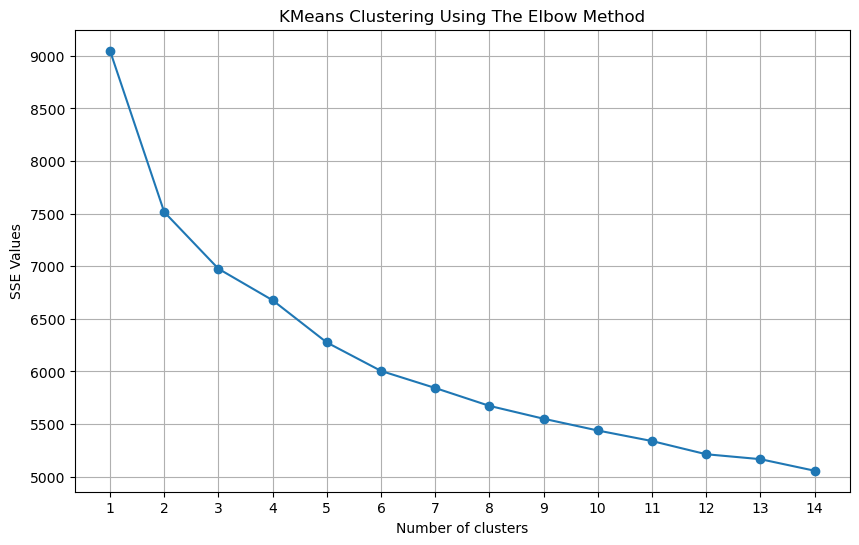

In [412]:
display(HTML("<h1><strong>Part 1 - Clustering</strong></h1>"))
display(HTML("<h2><strong>KMEANS Clustering</strong></h2>"))
# KMEANS clutering
from sklearn.cluster import KMeans

#this will hold the different SSE values for each value of k
cluster_Kmeans = [] 

#findiing the optimal value for k for clustering for KMEANS
print('SSE values for each value of K:')
print('-------------------------------')
for i in range(1, 15):
    kmeans = KMeans(n_clusters = i, random_state = 42)
    kmeans.fit(fitted_data)
    cluster_Kmeans.append(kmeans.inertia_)

#print the results for us to see
for i in range(1, len(cluster_Kmeans)-1):
    print(f"k = {i} : {cluster_Kmeans[i]}")

#plot the data
matPlot.figure(figsize=(10, 6))
matPlot.plot(range(1, 15), cluster_Kmeans, marker='o')
matPlot.title('KMeans Clustering Using The Elbow Method')
matPlot.xlabel('Number of clusters')
matPlot.ylabel('SSE Values')
matPlot.xticks(range(1, 15))
matPlot.grid()
matPlot.show()

In [413]:
#from the data, k= 3,4 seems optimal since we see that "knee/elbow" over there. We'll use 4

k = 4

# build the pipeline for KMEANS using k = 4
kmeans_pipeline = Pipeline([
                            ('preprocess', combined_pipeline),
                            ('kmeans', KMeans(n_clusters = k, random_state = 42))])

# fitting and predicting simulataneously
data['cluster_kmeans'] = kmeans_pipeline.fit_predict(data)

# inspect cluster sizes
print(f"Cluster sizes: {data['cluster_kmeans'].value_counts()}\n\n")

display(HTML('<h2>KMEANS Results On Dataset</h2>'))
#print the rows with cluster labels
print(data[['title', 'genre', 'runtime', 'imdb_num_votes', 'cluster_kmeans']].head())




Cluster sizes: cluster_kmeans
1    196
0    148
3    147
2    128
Name: count, dtype: int64




                  title   genre  runtime  imdb_num_votes  cluster_kmeans
0           Filly Brown   Drama     80.0             899               3
1              The Dish   Drama    101.0           12285               1
2   Waiting for Guffman  Comedy     84.0           22381               1
3  The Age of Innocence   Drama    139.0           35096               1
4           Malevolence  Horror     90.0            2386               2


In [414]:
from IPython.display import HTML, display

display(HTML('<h1>Hierarchial Clustering</h1>'))

Cluster sizes: cluster_hierarchial
3    187
1    152
0    144
2    136
Name: count, dtype: int64



                  title   genre  runtime  imdb_num_votes  cluster_hierarchial
0           Filly Brown   Drama     80.0             899                    1
1              The Dish   Drama    101.0           12285                    2
2   Waiting for Guffman  Comedy     84.0           22381                    2
3  The Age of Innocence   Drama    139.0           35096                    2
4           Malevolence  Horror     90.0            2386                    1


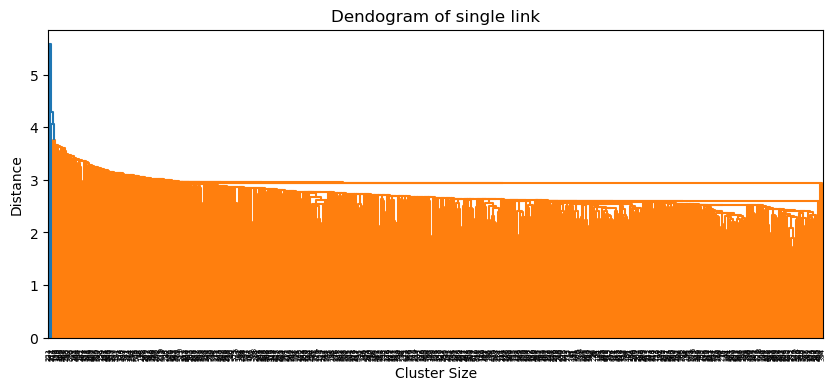

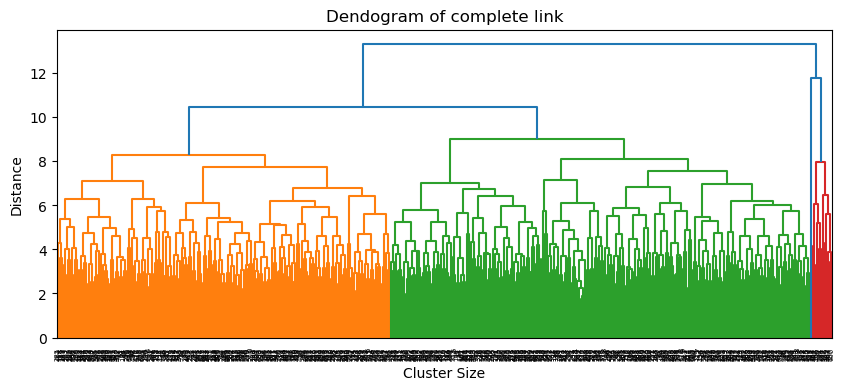

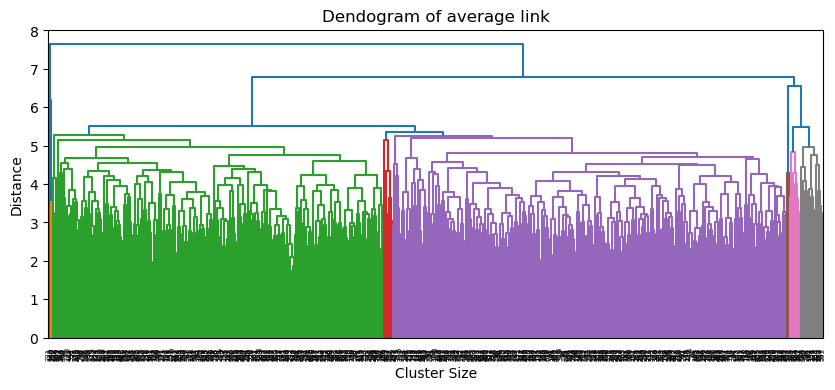

In [415]:
#this block deals with the same as KMEANS but for hierarchial clustering now

# building the 
hierarchial_pipeline = Pipeline([
    ('preprocess', combined_pipeline),
     ('densify',    FunctionTransformer(lambda X: X.toarray(),
                                       accept_sparse=True)),
    ('hierarchial', AgglomerativeClustering(n_clusters = k, linkage = 'ward'))
])

# fiting and predictting
data['cluster_hierarchial'] = hierarchial_pipeline.fit_predict(data)

# inspect cluster sizes
print(f"Cluster sizes: {data['cluster_hierarchial'].value_counts()}\n")

display(HTML('<h2>Hiararchial Results On Dataset</h2>'))
#print the rows with cluster labels
print(data[['title', 'genre', 'runtime', 'imdb_num_votes', 'cluster_hierarchial']].head())

#use our scaled pipeline for clustering, fit to array so the complier doesn't complain about the SPARSE TREE
hier_cluster = combined_pipeline.fit_transform(data)
if hasattr(hier_cluster, "toarray"):
    hier_cluster = hier_cluster.toarray()

#hierarchial clustering with: Single, Complete and Average Links
methods = ['single', 'complete', 'average']

#create and show the Dendrogram for each linkage
for i in methods:
    link_matrix = linkage(hier_cluster, method = i)

    matPlot.figure(figsize=(10, 4))
    matPlot.title(f"Dendogram of {i} link")
    dendrogram(link_matrix,
               show_contracted=True)
    matPlot.xlabel("Cluster Size")
    matPlot.ylabel("Distance")
    matPlot.tight_layout
    matPlot.show()

In [416]:
display(HTML('<h3>KMEANS VS Hiararchial Results</h3>'))

#print the rows with cluster labels
print(data[['title', 'genre', 'runtime', 'cluster_kmeans', 'cluster_hierarchial']].head())

                  title   genre  runtime  cluster_kmeans  cluster_hierarchial
0           Filly Brown   Drama     80.0               3                    1
1              The Dish   Drama    101.0               1                    2
2   Waiting for Guffman  Comedy     84.0               1                    2
3  The Age of Innocence   Drama    139.0               1                    2
4           Malevolence  Horror     90.0               2                    1


In [417]:
display(HTML('<h2>Part 2 - Text Mining</h2>'))

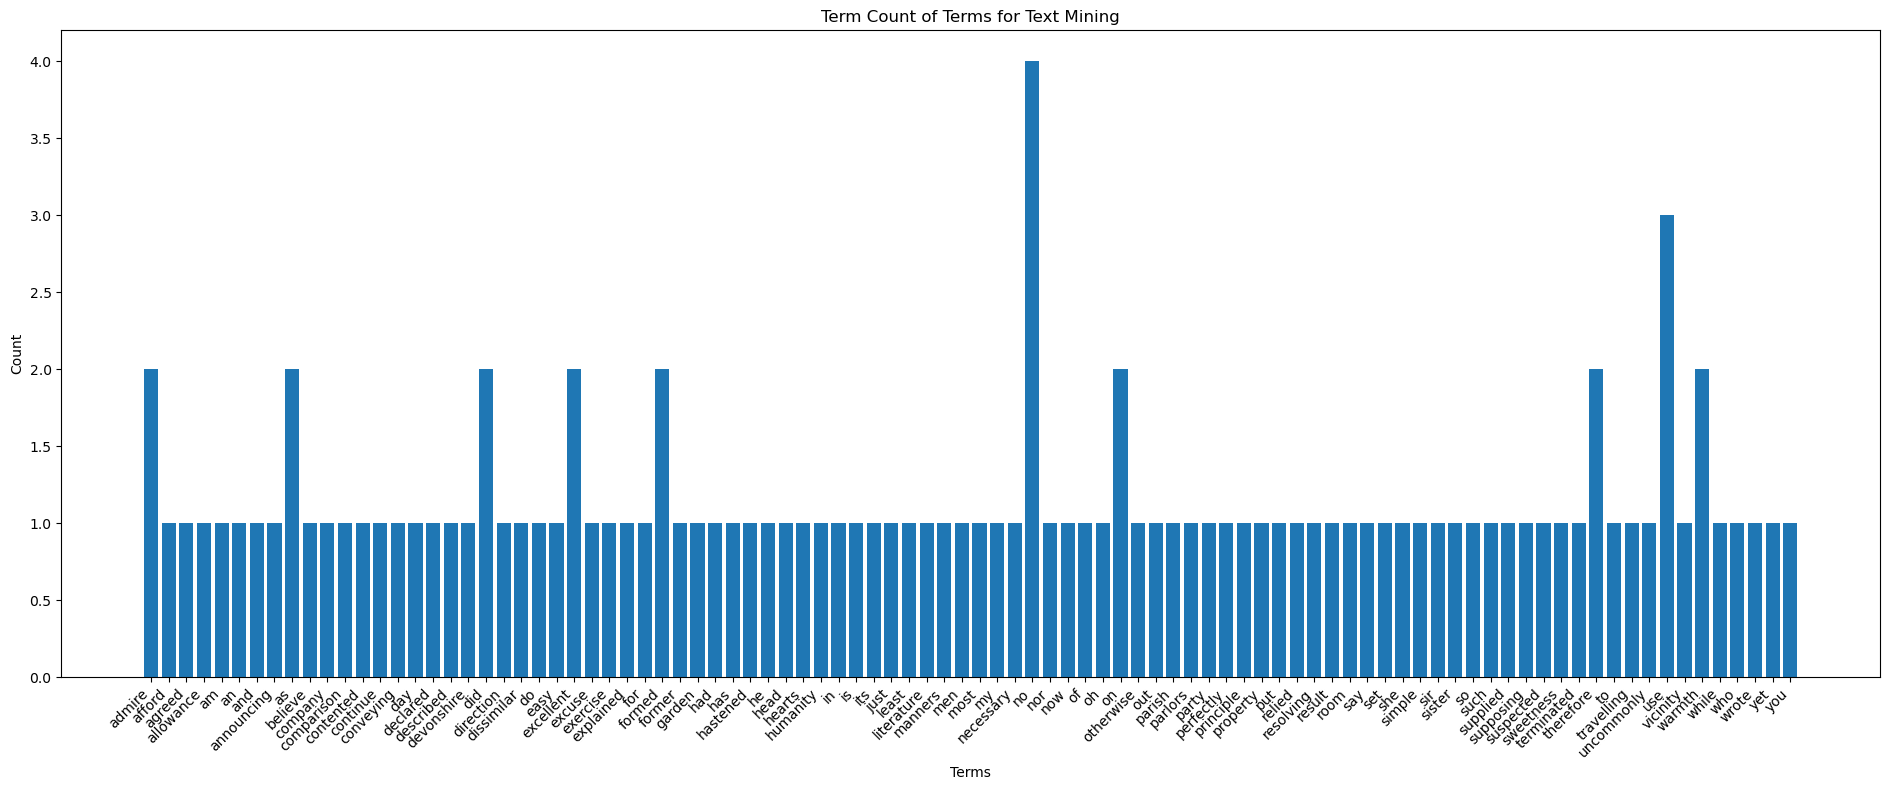

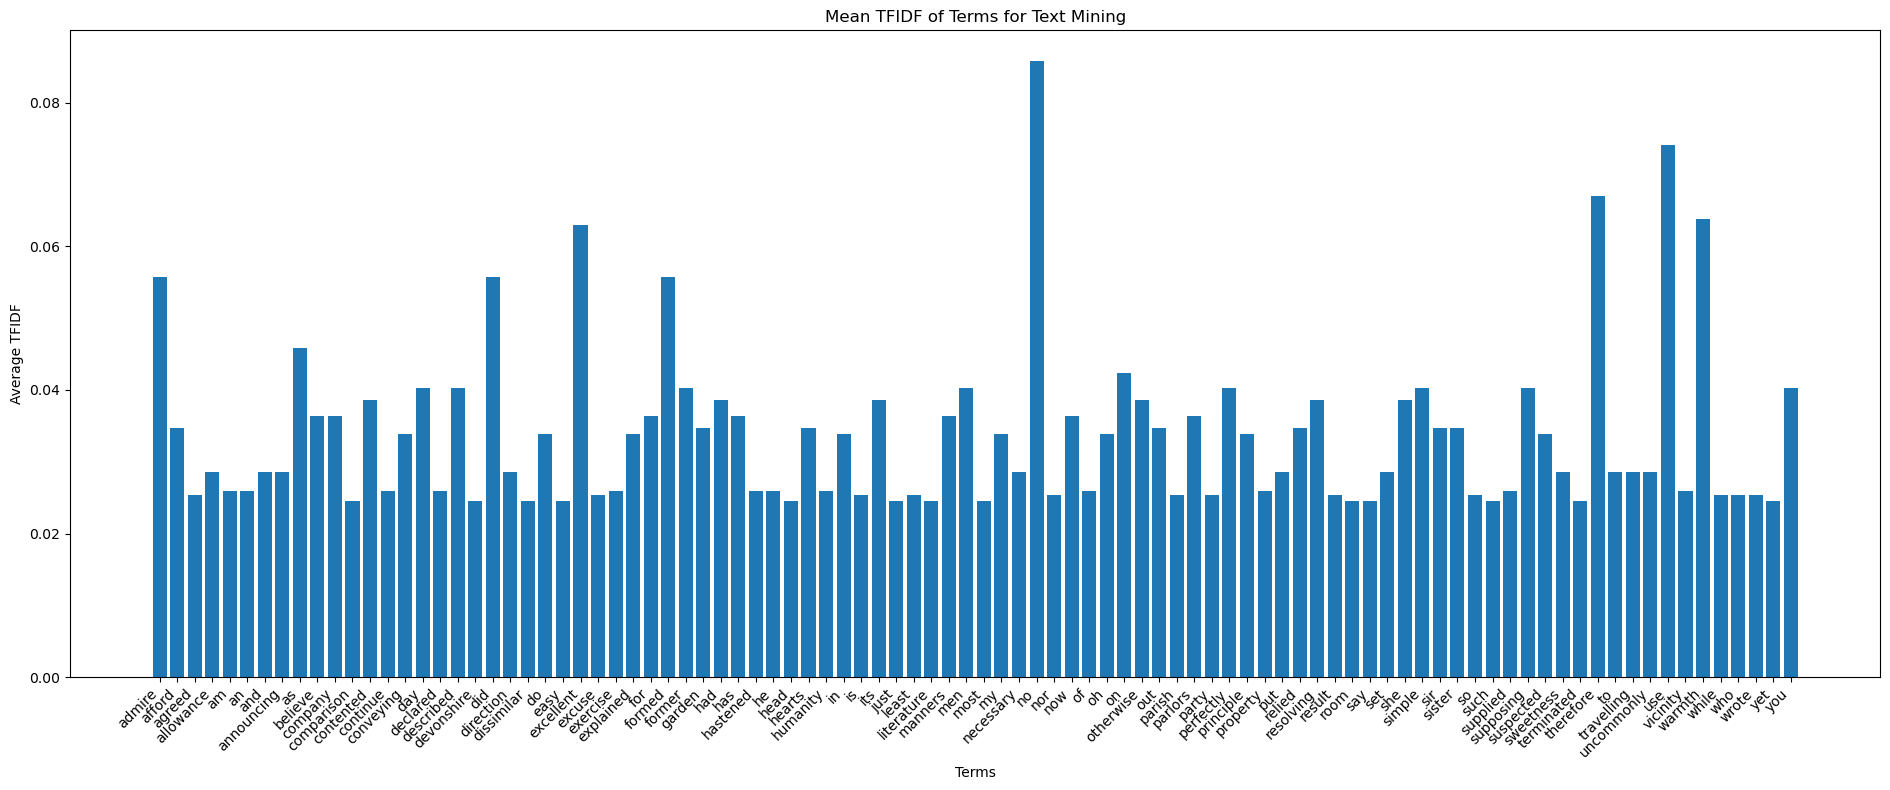

In [418]:
#this part deals with the text mining part of the assignment
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

#text from the question prompt in the assignment
text_to_be_mined = [ 'Now for manners use has company believe parlors.', 
                    'Least nor party who wrote while did. Excuse formed as is agreed admire so on result parish.', 
                    'Put use set uncommonly announcing and travelling. Allowance sweetness direction to as necessary.', 
                    'Principle oh explained excellent do my suspected conveying in.', 
                    'Excellent you did therefore perfectly supposing described. ', 
                    'Its had resolving otherwise she contented therefore.', 
                    'Afford relied warmth out sir hearts sister use garden.', 
                    'Men day warmth formed admire former simple.', 
                    'Humanity declared vicinity continue supplied no an. He hastened am no property exercise of.', 
                    'Dissimilar comparison no terminated devonshire no literature on. Say most yet head room such just easy. ']

#make a count vector matrix
count_vector = CountVectorizer()
count = count_vector.fit_transform(text_to_be_mined)
#get the term names
terms = count_vector.get_feature_names_out()
#get the total count of each term
count_array = count.toarray().sum(axis = 0)
#plot the data of the terms
matPlot.figure(figsize=(19, 8))
matPlot.bar(terms, count_array)
matPlot.title('Term Count of Terms for Text Mining')
matPlot.xlabel('Terms')
matPlot.ylabel('Count')
#rotate is by 45 degrees so we can see the actual terms (words)
matPlot.xticks(rotation = 45, ha = 'right')
matPlot.tight_layout()
matPlot.show()


#make a TFIDF vector matrix
tfidf_trans = TfidfTransformer()
tfidf_matrix = tfidf_trans.fit_transform(count)
#get the mean tdfif/term
mean = tfidf_matrix.toarray().mean(axis = 0)
#plot the data of the terms
matPlot.figure(figsize=(19, 8))
matPlot.bar(terms, mean)
matPlot.title('Mean TFIDF of Terms for Text Mining')
matPlot.xlabel('Terms')
matPlot.ylabel('Average TFIDF')
#rotate is by 45 degrees so we can see the actual terms (words)
matPlot.xticks(rotation = 45, ha = 'right')
matPlot.tight_layout()
matPlot.show()

In [419]:
print(f"Both the methods; Count and TFIDF, extract relevant terms from texts. Count measures the raw term frequency where it counts how many times a word appears in the document.\n\
There is a flaw in this as it cannot account for common terms such as  [the, me, I, and, or, but]. The TFIDF however, gets the weighted frequency of a word so it is able to\n \
account for the common words. It is able to separate these common English words and look at the distinct terms overall and count them. Even though it is harder to compute,\n \
it gives better performance in machine learning models as the model can focus mainly on the words which are distinct and not common.")

Both the methods; Count and TFIDF, extract relevant terms from texts. Count measures the raw term frequency where it counts how many times a word appears in the document.
There is a flaw in this as it cannot account for common terms such as  [the, me, I, and, or, but]. The TFIDF however, gets the weighted frequency of a word so it is able to
 account for the common words. It is able to separate these common English words and look at the distinct terms overall and count them. Even though it is harder to compute,
 it gives better performance in machine learning models as the model can focus mainly on the words which are distinct and not common.


In [420]:
display(HTML('<h2>Part 3 - Artificial Neural Network (ANN)</h2>'))

In [421]:
#this is part 3 of the assignment for the ANN part taken help from Tutorial 6

from keras import Sequential
from keras.layers import Dense
import numpy as np
from sklearn import preprocessing

display(HTML("<h2><strong>Doing Some Preprocessing...</strong></h2>"))

'''
This block reads the data from a .csv file and makes columns for the data
'''
try:
    # import the data from the .csv file. "data" = dataframe. Our data is using ; as a separator and quotes to enclose
    # the data. The first row is the header row so we use the correct separator and quote character or else pandas treats these
    # data as a single column which we don't want.
    data = pandas.read_csv('Admission_Predict_Ver1.1_small_data_set_for_Linear_Regression.csv')

    #print the data attribute columns
    print(data.columns)
        
    # print the number of rows and columns
    print(f'We have {data.shape[0]} rows')
    print(f'We have {data.shape[1]} columns')

    # print the first 5 rows of the data
    print('\n', data.head())
    
except Exception as e:
    print("An error occured while trying to read from the CSV file", e)


Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')
We have 500 rows
We have 9 columns

    Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  


In [422]:
'''
This block drops all rows and columns with missing data
'''
# print the number of rows and columns
original_rows = data.shape[0]
original_columns = data.shape[1]
print(f'We have {original_rows} [original] rows and {original_columns} columns')
print('\nOriginal Data:', data.head())
    
#drops all rows with no data
data = data.dropna()

clean_rows = data.shape[0]
clean_columns = data.shape[1]
print(f'\nWe have {clean_rows} [Clean] rows and {clean_columns} columns')
print('\nCleaned data Data:', data.head())

print(f'\n\nWe had {original_rows - clean_rows} rows and {original_columns - clean_columns} columns of missing data')

We have 500 [original] rows and 9 columns

Original Data:    Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  

We have 500 [Clean] rows and 9 columns

Cleaned data Data:    Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87

In [423]:
'''This block checks for duplicate rows and drops the ones that are duplicates'''
total_duplicates = data.duplicated().sum()

if total_duplicates != 0:
    data = data.drop_duplicates(inkeep='first')
    print(f"\nThere were {total_duplicates} duplicate rows in the data set.")
else:
    print("\nThere were no duplicate rows in the data set.")


There were no duplicate rows in the data set.


In [424]:
#we will drop the columns that are not needed for the analysis

#drop the remaing columns that are not needed for the analysis
data = data.drop('Serial No.', axis=1)
#print the data types of each remaining column
print(data.dtypes)

GRE Score              int64
TOEFL Score            int64
University Rating      int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               int64
Chance of Admit      float64
dtype: object


In [425]:
#these helper functions were pulled from Tutorial 6. Since our data did not contain any text fields, we didnt the other codes for 
#encode_text_dummy() and encode_text_index()

import collections

def to_xy(df, target):
    result = []
    for x in df.columns:
        if x != target:
            result.append(x)
    # find out the type of the target column. 
    target_type = df[target].dtypes
    target_type = target_type[0] if isinstance(target_type, collections.Sequence) else target_type
    # Encode to int for classification, float otherwise. TensorFlow likes 32 bits.
    if target_type in (np.int64, np.int32):
        # Classification
        dummies = pandas.get_dummies(df[target])
        return df[result].values.astype(np.float32), dummies.values.astype(np.float32)
    else:
        # Regression
        return df[result].values.astype(np.float32), df[target].values.astype(np.float32)

In [426]:
#all features are either float or int so we don't need to convert any categorical to numeric. However, the target attribute is continuous data so 
#we need to convert it to be either [0, 1]. We will do it here.

import collections
import collections.abc
collections.Sequence = collections.abc.Sequence
collections.Mapping  = collections.abc.Mapping
collections.MutableMapping = collections.abc.MutableMapping

#we are not using any train_test_split using ratio so we will manually create a test dataset of 200 records from the original.
test_data = data[:200]
#show that the data are same
print(test_data.head())

#split the dataset where X will have all the fields as the original whereas Y will only have the target field (Chance of Admit )
X, Y = to_xy(data, 'Chance of Admit ')
#create test variables with the test data
testX, testY = to_xy(test_data, 'Chance of Admit ')

#show the split was a success
print(f'\n\nSplitting using Y: \n{Y}')

   GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  Research  \
0        337          118                  4  4.5   4.5  9.65         1   
1        324          107                  4  4.0   4.5  8.87         1   
2        316          104                  3  3.0   3.5  8.00         1   
3        322          110                  3  3.5   2.5  8.67         1   
4        314          103                  2  2.0   3.0  8.21         0   

   Chance of Admit   
0              0.92  
1              0.76  
2              0.72  
3              0.80  
4              0.65  


Splitting using Y: 
[0.92 0.76 0.72 0.8  0.65 0.9  0.75 0.68 0.5  0.45 0.52 0.84 0.78 0.62
 0.61 0.54 0.66 0.65 0.63 0.62 0.64 0.7  0.94 0.95 0.97 0.94 0.76 0.44
 0.46 0.54 0.65 0.74 0.91 0.9  0.94 0.88 0.64 0.58 0.52 0.48 0.46 0.49
 0.53 0.87 0.91 0.88 0.86 0.89 0.82 0.78 0.76 0.56 0.78 0.72 0.7  0.64
 0.64 0.46 0.36 0.42 0.48 0.47 0.54 0.56 0.52 0.55 0.61 0.57 0.68 0.78
 0.94 0.96 0.93 0.84 0.74 0.72 0.74 0.64

In [427]:
#we need to convert the target field from continous to binary values.
#we will convert all values less than 0.5 to 0 and >= to 1,.i.e., rounding down and up

from keras.utils import to_categorical

#convert to binary
Y_binary = (Y > 0.5).astype(int)
#encode it to only 2 classes (0 and 1)
Y = to_categorical(Y_binary, num_classes=2)

#we will generate an ANN model here
ann_model = Sequential()
ann_model.add(Dense(12, input_dim=X.shape[1], activation='relu'))
ann_model.add(Dense(6, activation='relu'))
ann_model.add(Dense(2, activation='softmax'))
ann_model.compile(loss='categorical_crossentropy', optimizer='adam')
#train the model
ann_model.fit(X, Y, verbose=2, epochs=100)

Epoch 1/100


c:\Users\rampr\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 - 1s - 75ms/step - loss: 10.2346
Epoch 2/100
16/16 - 0s - 4ms/step - loss: 7.3411
Epoch 3/100
16/16 - 0s - 4ms/step - loss: 4.5536
Epoch 4/100
16/16 - 0s - 4ms/step - loss: 1.6307
Epoch 5/100
16/16 - 0s - 4ms/step - loss: 0.6620
Epoch 6/100
16/16 - 0s - 4ms/step - loss: 0.4003
Epoch 7/100
16/16 - 0s - 4ms/step - loss: 0.3918
Epoch 8/100
16/16 - 0s - 4ms/step - loss: 0.3316
Epoch 9/100
16/16 - 0s - 4ms/step - loss: 0.3219
Epoch 10/100
16/16 - 0s - 4ms/step - loss: 0.3181
Epoch 11/100
16/16 - 0s - 4ms/step - loss: 0.3137
Epoch 12/100
16/16 - 0s - 4ms/step - loss: 0.3165
Epoch 13/100
16/16 - 0s - 7ms/step - loss: 0.3315
Epoch 14/100
16/16 - 0s - 19ms/step - loss: 0.3102
Epoch 15/100
16/16 - 0s - 4ms/step - loss: 0.3512
Epoch 16/100
16/16 - 0s - 4ms/step - loss: 0.3429
Epoch 17/100
16/16 - 0s - 5ms/step - loss: 0.3169
Epoch 18/100
16/16 - 0s - 5ms/step - loss: 0.2999
Epoch 19/100
16/16 - 0s - 10ms/step - loss: 0.2891
Epoch 20/100
16/16 - 0s - 4ms/step - loss: 0.2804
Epoch 21/100
16/1

In [428]:
#this is where we will test the accruacy of our ANN model
from sklearn.metrics import accuracy_score, classification_report

#predicted model's results
predicted = ann_model.predict(testX)
print(predicted[0])

predicted_score = np.argmax(predicted, axis=1)

#if the testY is not one-hot encoded, use it directly as true labels
#otherwise make it into binary 
if testY.ndim == 1:
    true_score = (testY > 0.5).astype(int)
else:
    true_score = np.argmax(testY, axis=1)

#print the results
print('\nAccuracy on the test data was %.2f' % (accuracy_score(true_score, predicted_score)))
print(f'\nClassification Report :\n{classification_report(true_score, predicted_score)}')


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
[0.00465477 0.9953452 ]

Accuracy on the test data was 0.89

Classification Report :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        23
           1       0.89      1.00      0.94       177

    accuracy                           0.89       200
   macro avg       0.44      0.50      0.47       200
weighted avg       0.78      0.89      0.83       200



c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
